In [49]:
# Header for the notebook
from datetime import datetime
from IPython.display import display, Markdown

# Get the current date
title = "Characterization of cerebellar tremor across standardized upper-limb tasks using smartphone accelerometry Phyhox"
current_date = datetime.now().strftime("%d %B %Y, %H:%M:%S")
authors = "Sofia ZEMMAHI (and Copilot) - M2 REHAB MAP"

# Insert the date into the notebook
display(Markdown(f"# {title}"))
display(Markdown(f"{current_date}"))
display(Markdown(f"by {authors}"))

# Characterization of cerebellar tremor across standardized upper-limb tasks using smartphone accelerometry Phyhox

27 April 2026, 10:47:39

by Sofia ZEMMAHI (and Copilot) - M2 REHAB MAP

## ----------------------  DAY 1 ---------------------------------------------

In [50]:
import pandas as pd

df = pd.read_csv("data/raw_data/J1_P01.csv")
df.head()

,Time (s),X (m/s^2),Y (m/s^2),Z (m/s^2)
0,0.002665,0.506471,-0.356188,0.234163
1,0.012697,0.032052,-0.225771,-0.058613
2,0.022728,-1.409056,0.168511,-0.354232
3,0.032759,-0.614877,0.402211,-0.335070
4,0.042790,-0.136440,0.013456,-0.319703


In [51]:
print(df.columns)
print(df.shape)

Index(['Time (s)', 'X (m/s^2)', 'Y (m/s^2)', 'Z (m/s^2)'], dtype='object')
(54558, 4)


## 1. The Signal

Plot the raw signals


- X axis : 

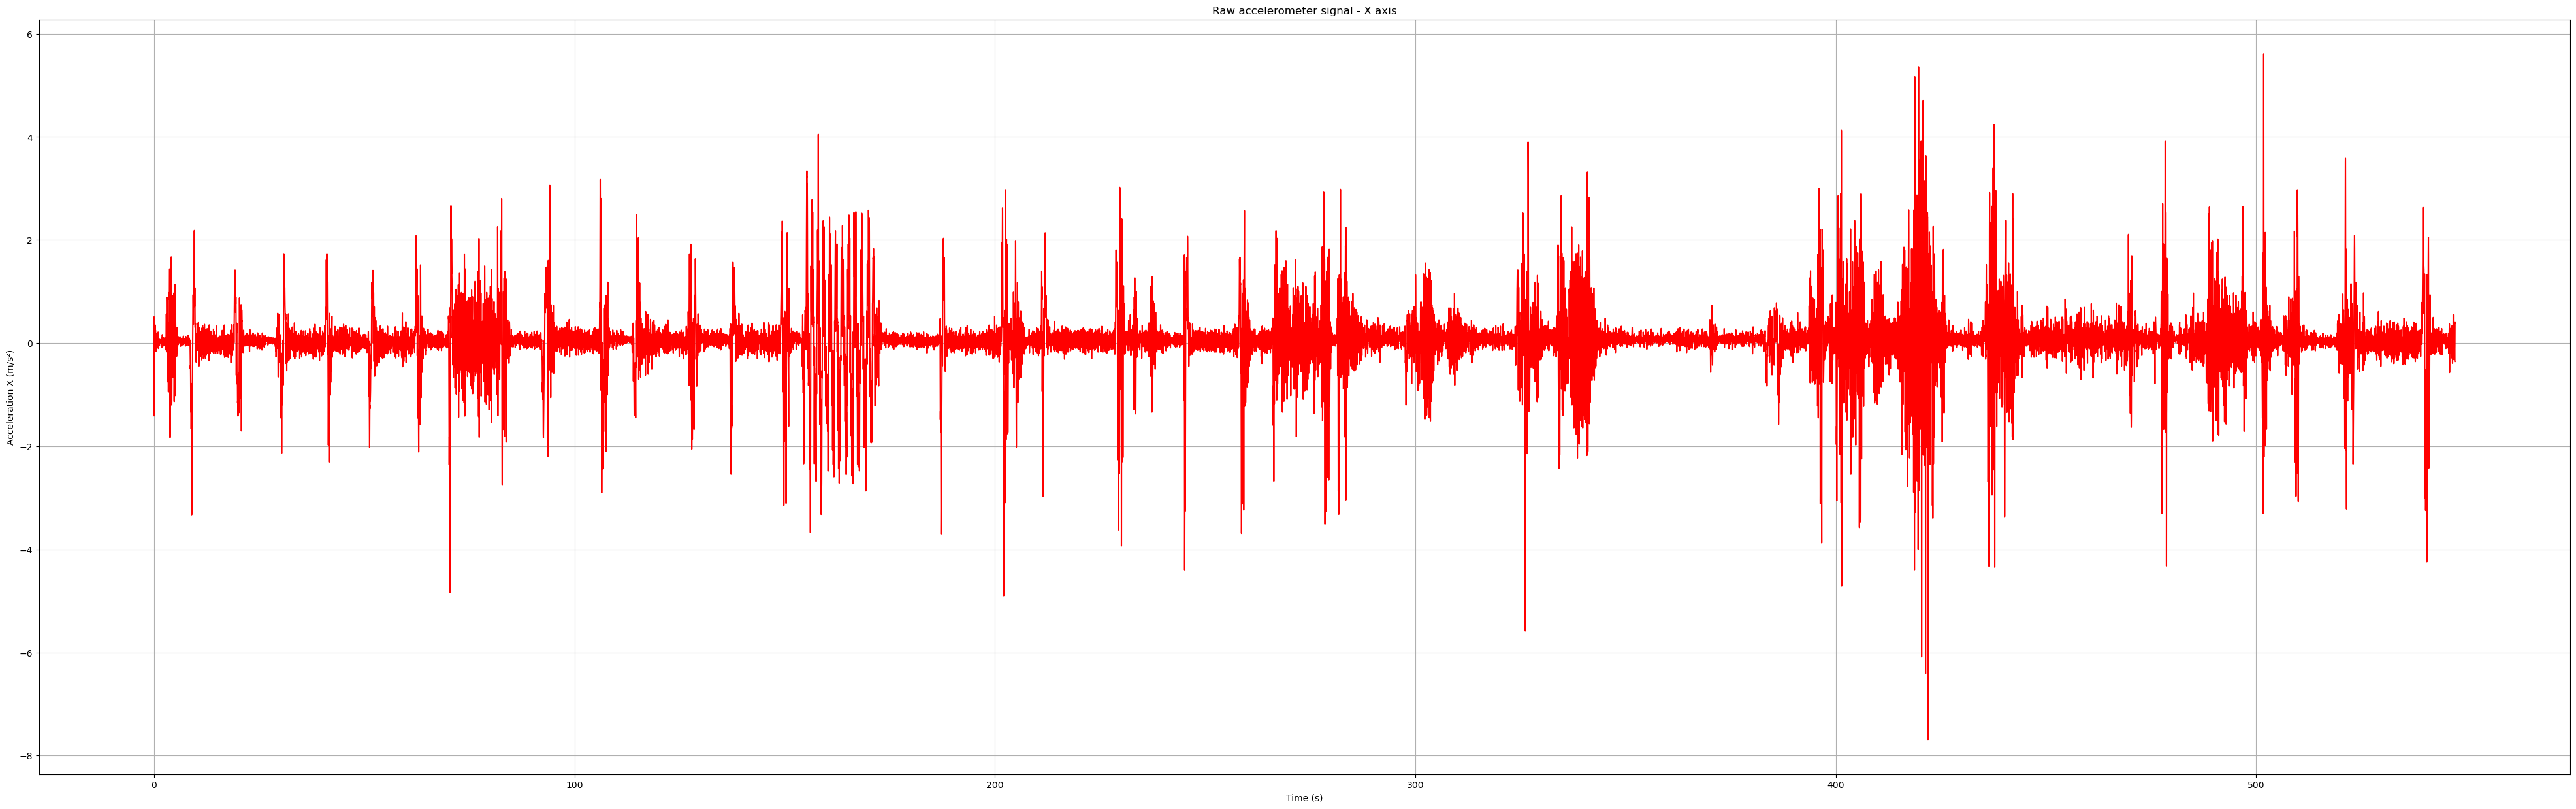

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(50,15))
plt.plot(df["Time (s)"], df["X (m/s^2)"], color="red")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration X (m/s²)")
plt.title("Raw accelerometer signal - X axis")
plt.grid(True)
plt.box(True)
plt.show()

- Y axis : 

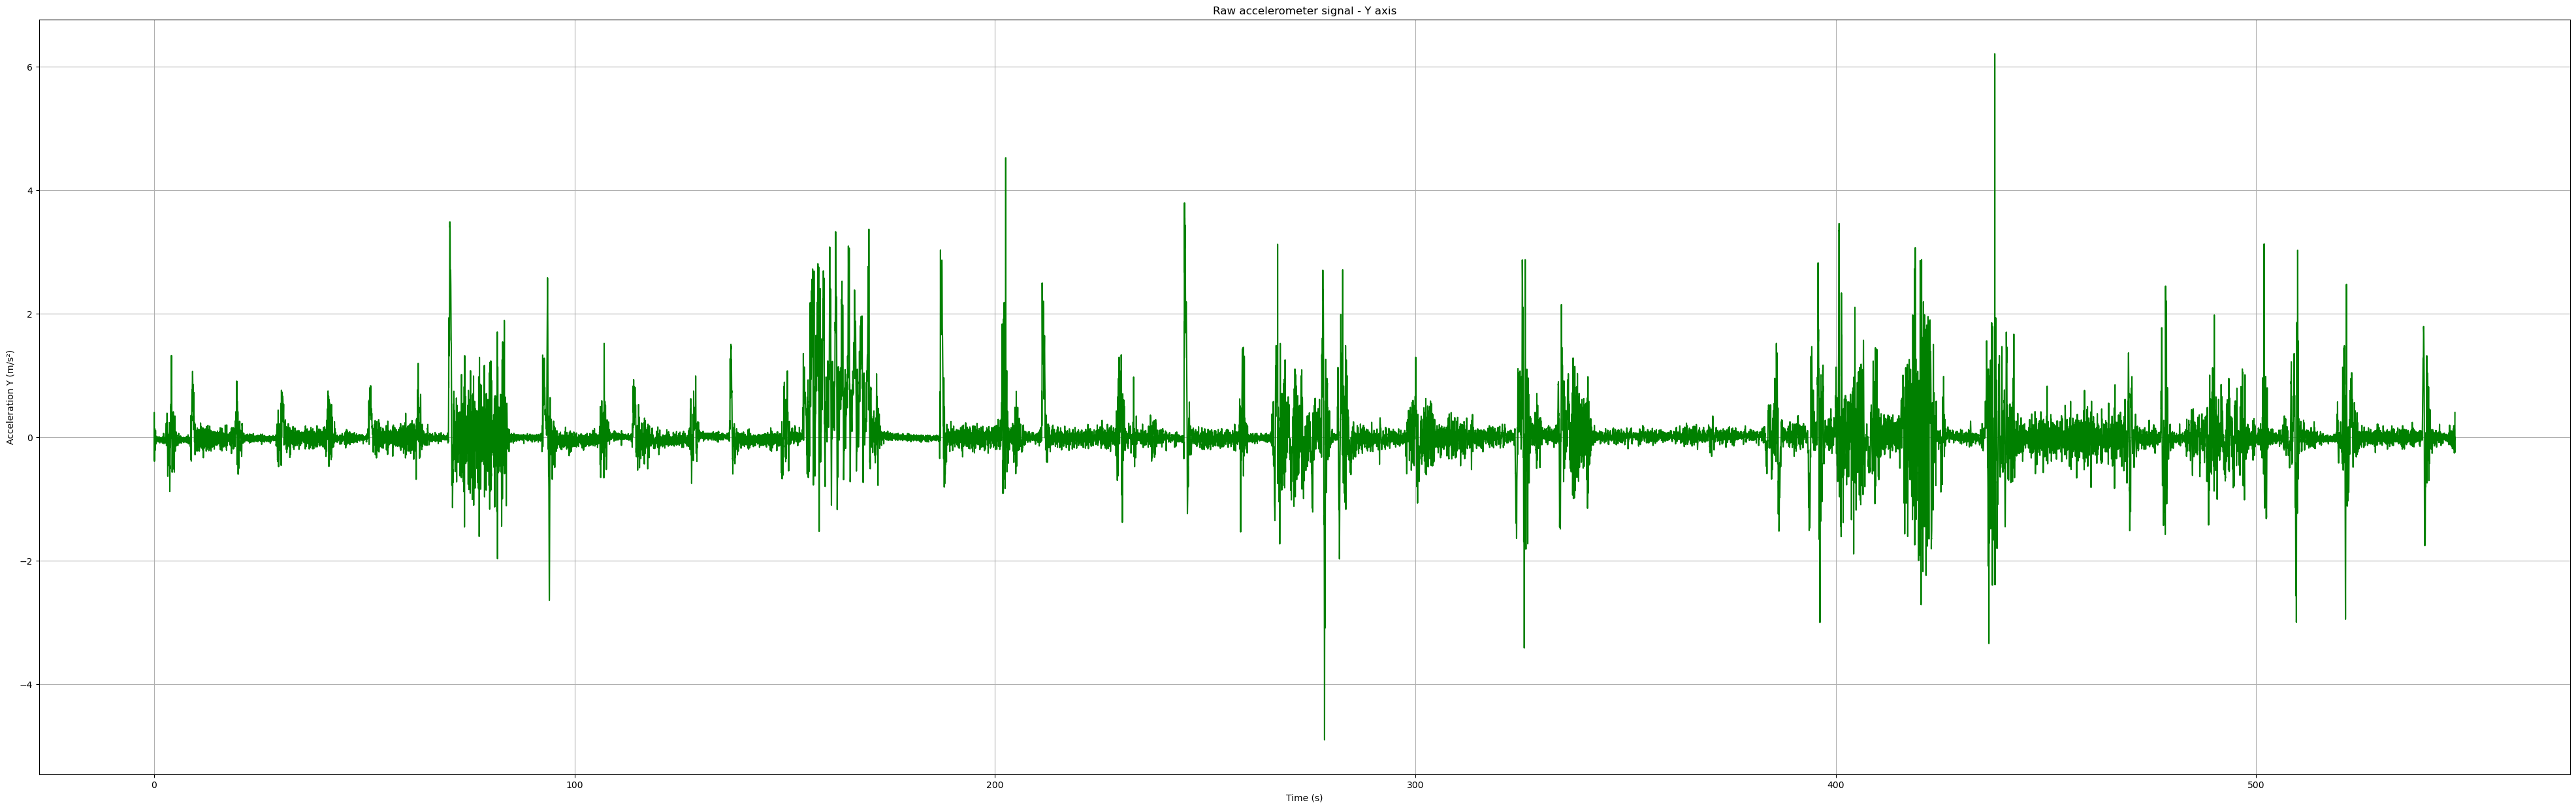

In [53]:
plt.figure(figsize=(50,15))
plt.plot(df["Time (s)"], df["Y (m/s^2)"], color="green")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration Y (m/s²)")
plt.title("Raw accelerometer signal - Y axis")
plt.grid(True)
plt.box(True)
plt.show()

- Z axis : 

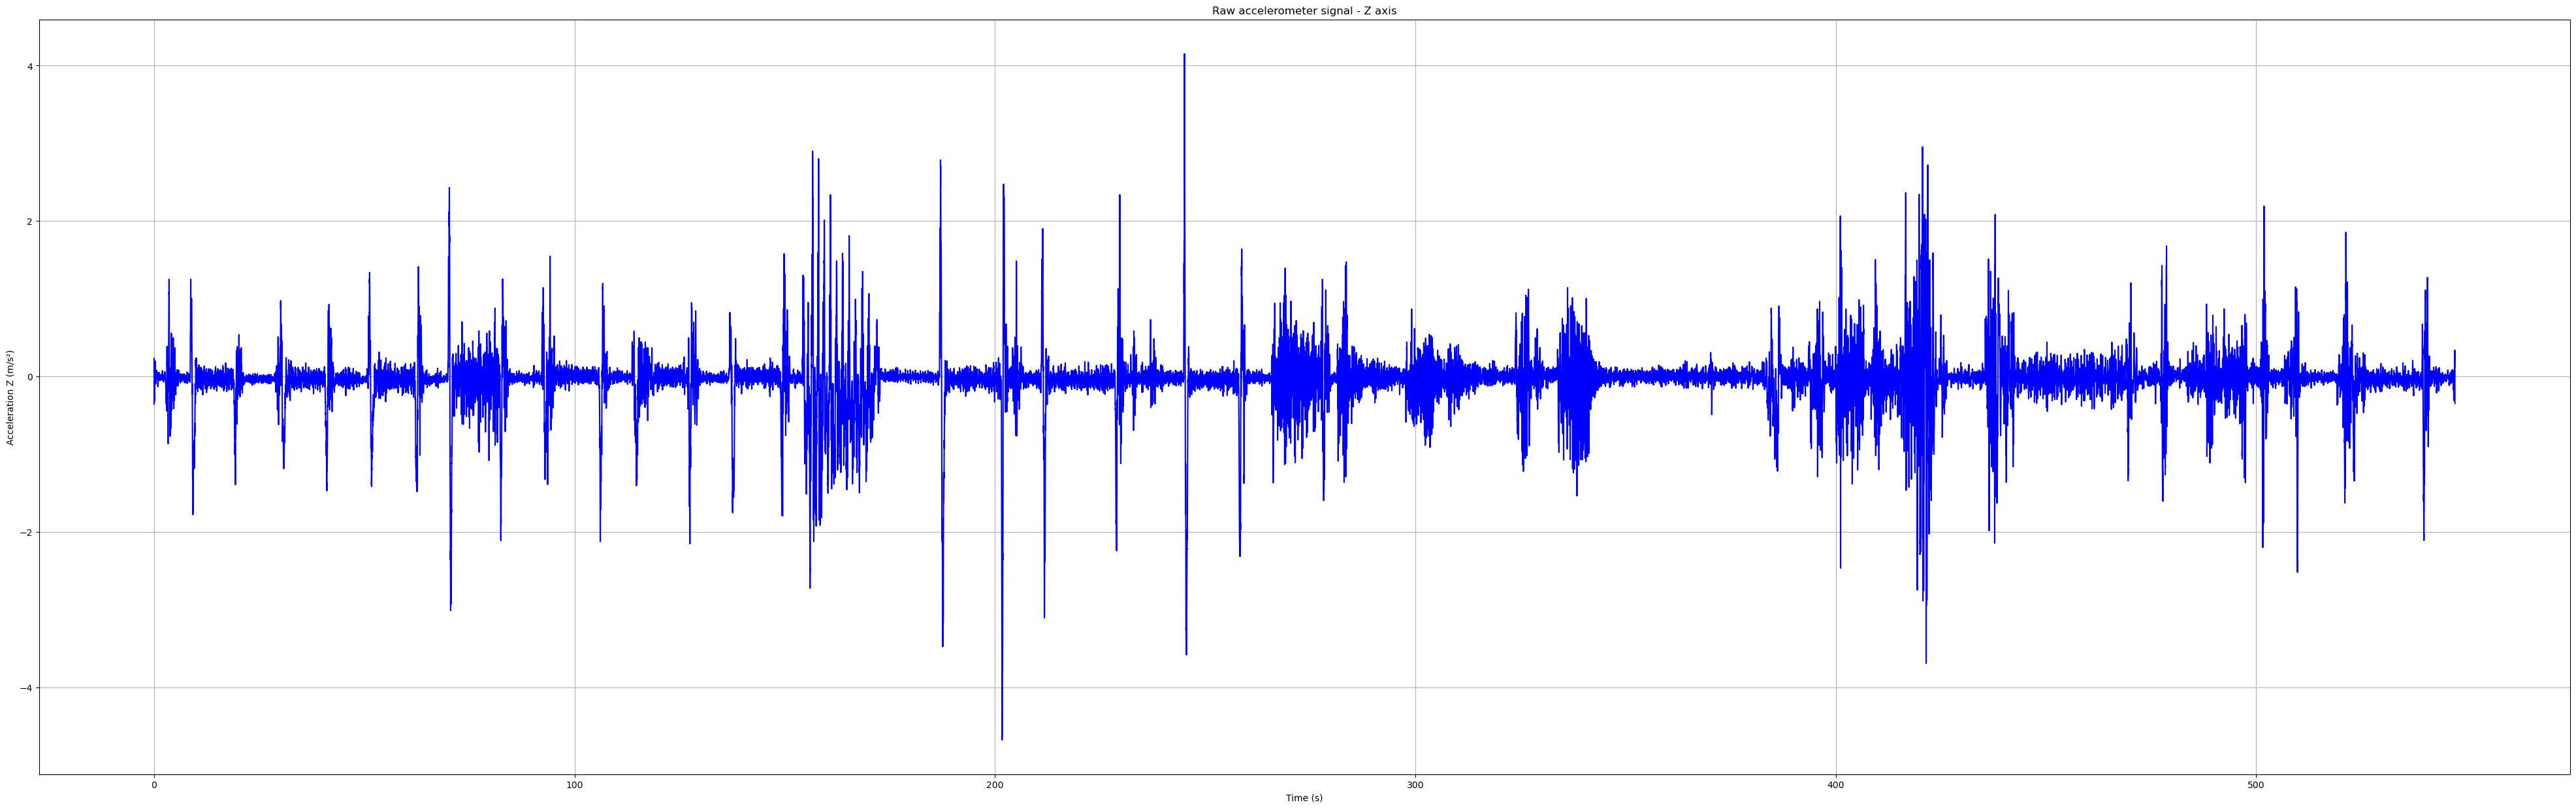

In [54]:
plt.figure(figsize=(50,15))
plt.plot(df["Time (s)"], df["Z (m/s^2)"], color="blue")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration Z (m/s²)")
plt.title("Raw accelerometer signal - Z axis")
plt.grid(True)
plt.box(True)
plt.show()

- The Global Signal :

The magnitude of the accelerometer signal was calculated as the Euclidean norm of the three axes (X, Y, Z), providing a single signal that reflects the overall intensity of movement regardless of its direction.




We will compare the rest phase befor ansd after with a functionnal task wich is a grasping task of taking a glass and drink water. 
The signal was segmented into three phases based on the timeline: 
- 9,3 econd rest period before the task
- 18,75 second drinking task phase
- 10 second rest period after the task.

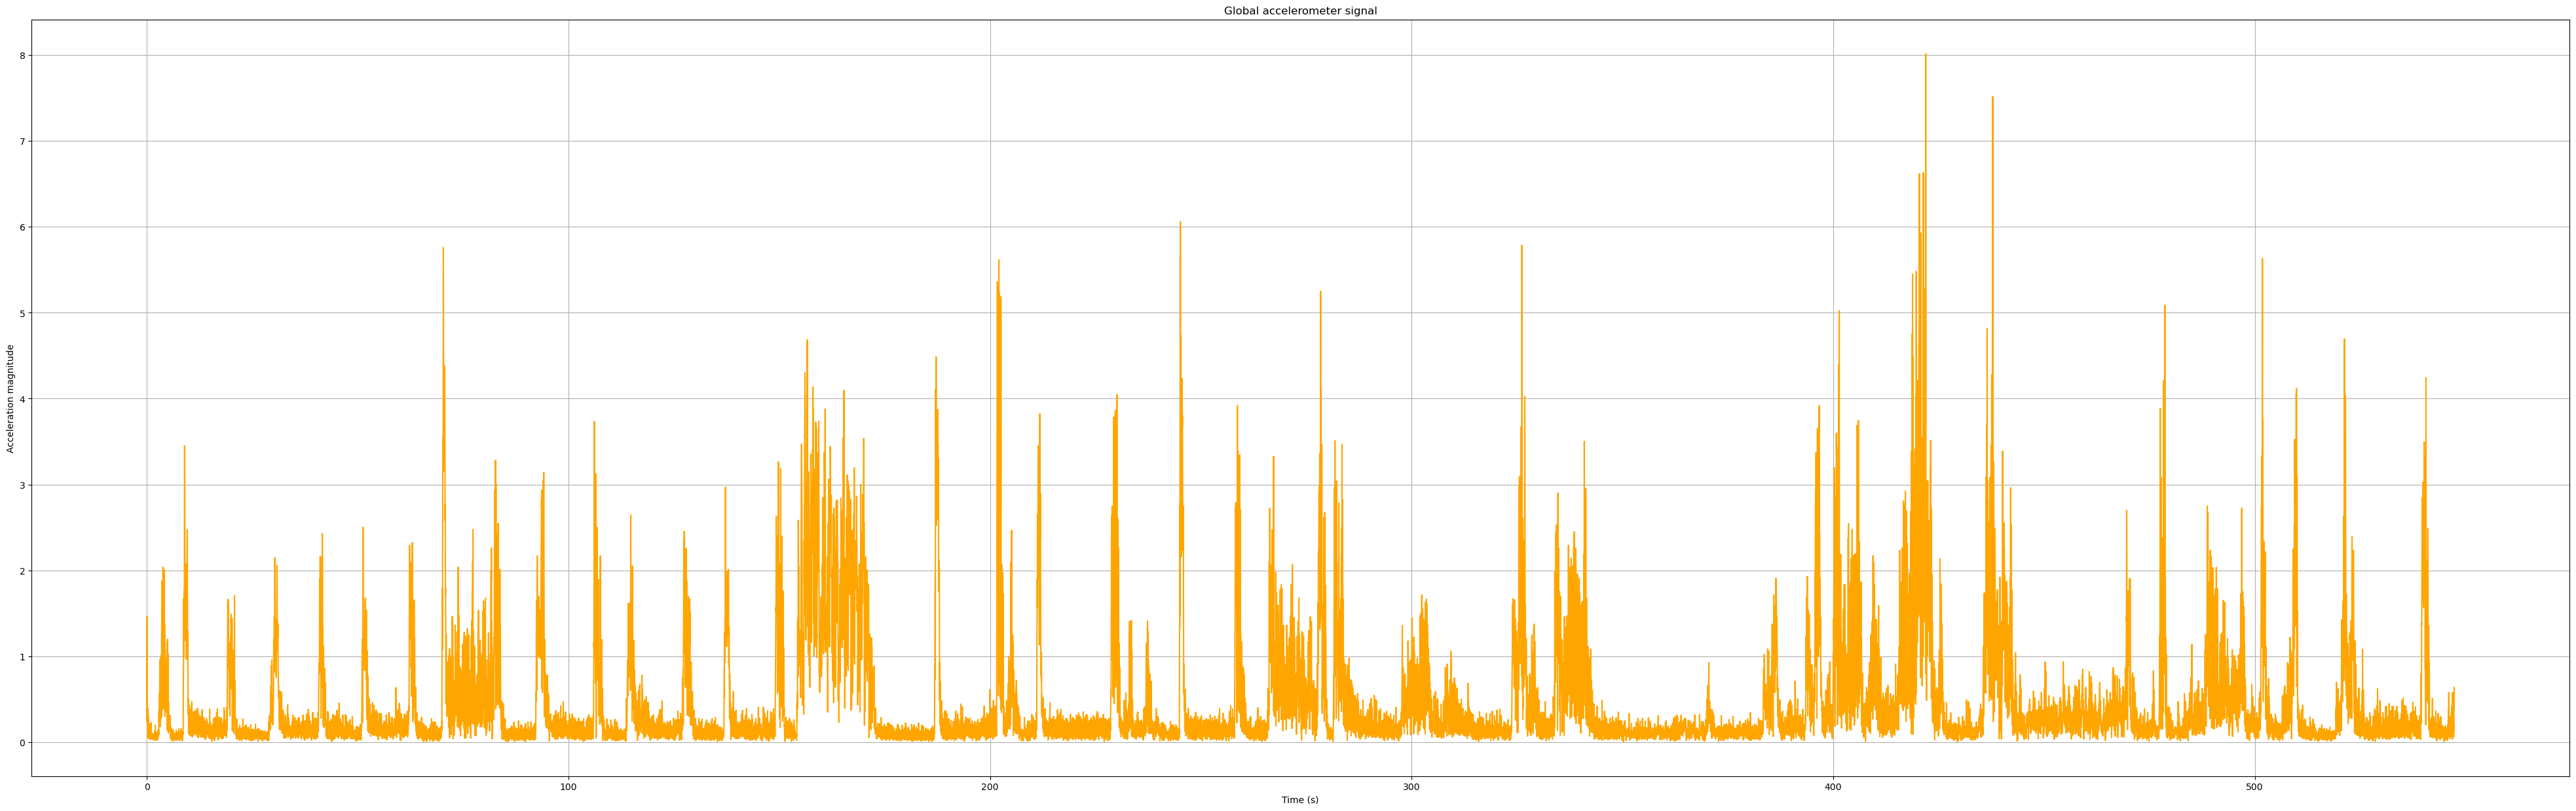

In [55]:
import numpy as np

df["magnitude"] = np.sqrt(
    df["X (m/s^2)"]**2 +
    df["Y (m/s^2)"]**2 +
    df["Z (m/s^2)"]**2
)

plt.figure(figsize=(50,15))
plt.plot(df["Time (s)"], df["magnitude"], color="orange")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude")
plt.title("Global accelerometer signal")
plt.grid(True)
plt.show()

Zoom on the task window : 


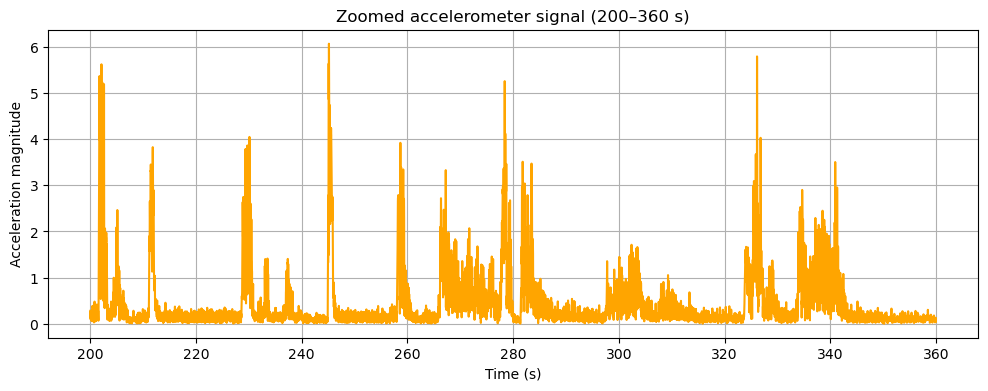

In [56]:
import matplotlib.pyplot as plt

# Sélection du segment
zoom_segment = df[(df["Time (s)"] >= 200) & (df["Time (s)"] <= 360)]

plt.figure(figsize=(12,4))

# Signal
plt.plot(zoom_segment["Time (s)"], zoom_segment["magnitude"], color="orange")

plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude")
plt.title("Zoomed accelerometer signal (200–360 s)")
plt.grid(True)

plt.show()

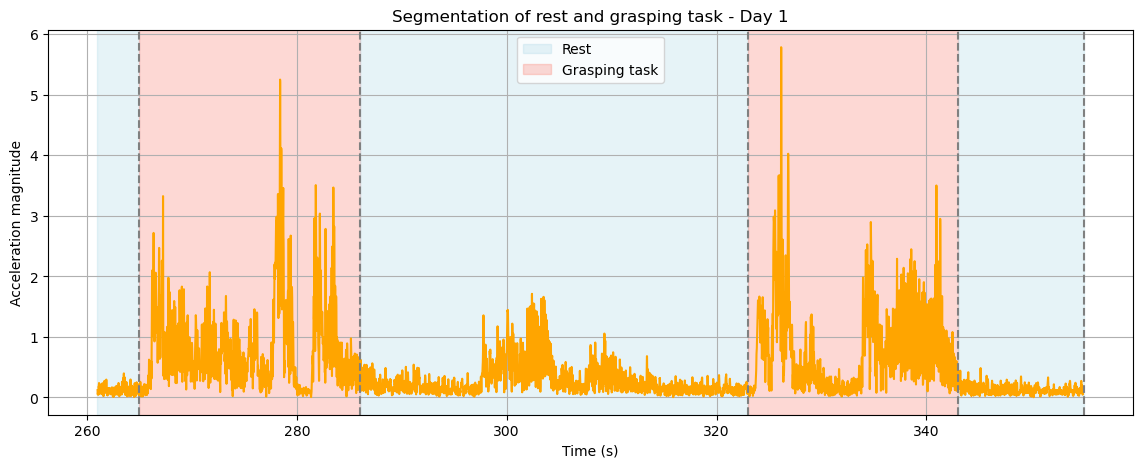

In [57]:
import matplotlib.pyplot as plt

# Segment times for Day 1
start_total = 261
rest1_start = 261
rest1_end = 265

task1_start = 265
task1_end = 286

rest2_start = 286
rest2_end = 323

task2_start = 323
task2_end = 343

rest3_start = 343
rest3_end = 355
end_total = 355

# Select the segment
segment_j1 = df[(df["Time (s)"] >= start_total) & (df["Time (s)"] <= end_total)]

plt.figure(figsize=(14,5))

# Plot signal
plt.plot(segment_j1["Time (s)"], segment_j1["magnitude"], color="orange")

# Background colors
plt.axvspan(rest1_start, rest1_end, color="lightblue", alpha=0.3, label="Rest")
plt.axvspan(task1_start, task1_end, color="salmon", alpha=0.3, label="Grasping task")
plt.axvspan(rest2_start, rest2_end, color="lightblue", alpha=0.3)
plt.axvspan(task2_start, task2_end, color="salmon", alpha=0.3)
plt.axvspan(rest3_start, rest3_end, color="lightblue", alpha=0.3)

# Separation lines
for x in [rest1_end, task1_end, rest2_end, task2_end, rest3_end]:
    plt.axvline(x, linestyle="--", color="gray")

# Labels
plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude")
plt.title("Segmentation of rest and grasping task - Day 1")
plt.grid(True)
plt.legend()

plt.show()


During the resting period between the two grasping tasks, a low-amplitude residual signal is still observable. This background activity reflect small involuntary movements. 

The signal amplitude during rest significantly lower than during the grasping task, confirming a clear distinction between active ans resting phases.

-----------------------------------------------------------------------------------------------------------------------------------

## Frequency analysis of the signal

To characterize the tremor, the accelerometer signal was transformed into the frequency domain using a Fast Fourier Transform (FFT). 

The analysis was performed separately for each segment (rest and grasping tasks) previously identified. 

To focus on tremor-related activity, only the frequency band between 3 and 8 Hz was considered, as this range corresponds to typical cerebellar tremor frequencies.
Now we can answer the question : 

**" What is the frequency of the tremor oscillation ?"**

-----------------------------------------------------------------------------------------------------------------------------------
### Rest 1 – Frequency analysis
The first rest phase was isolated, and the dominant frequency was computed using FFT.

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Define Rest 1
rest1 = df[(df["Time (s)"] >= 261) & (df["Time (s)"] <= 265)]

# Signal
signal_rest1 = rest1["magnitude"].values

# Remove mean
signal_centered_rest1 = signal_rest1 - np.mean(signal_rest1)

# Sampling frequency
fs = 100

# FFT
fft_vals_rest1 = np.abs(np.fft.fft(signal_centered_rest1))
freqs_rest1 = np.fft.fftfreq(len(signal_centered_rest1), d=1/fs)

# Keep positive frequencies
positive_freqs_rest1 = freqs_rest1[:len(freqs_rest1)//2]
positive_fft_rest1 = fft_vals_rest1[:len(fft_vals_rest1)//2]

# Mask 3–5 Hz
mask_rest1 = (positive_freqs_rest1 >= 3) & (positive_freqs_rest1 <= 5)

print("Dominant frequency - Rest 1:", dominant_freq_rest1, "Hz")

Dominant frequency - Rest 1: 3.266331658291457 Hz


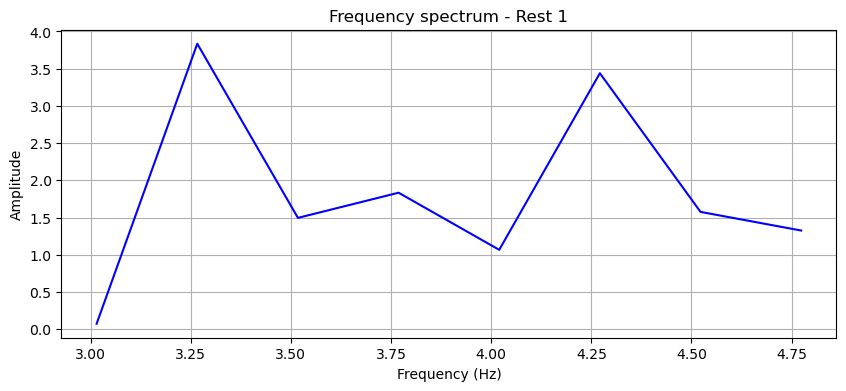

In [59]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest1[mask_rest1], positive_fft_rest1[mask_rest1], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Rest 1")
plt.grid(True)
plt.show()

The dominant frequency observed during the task (~5.2 Hz) falls within the range reported for cerebellar tremor (typically 3–5 Hz). This supports the hypothesis that the observed oscillations correspond to an intention tremor.

In contrast, although a frequency was detected during rest, its very low amplitude suggests that it reflects background noise rather than a true tremor.

In [60]:
signal_rest1 = rest1["magnitude"].values
signal_centered_rest1 = signal_rest1 - np.mean(signal_rest1)

rms_rest1 = np.sqrt(np.mean(signal_centered_rest1**2))
print("RMS amplitude - Rest 1:", rms_rest1)

RMS amplitude - Rest 1: 0.07145669545825618


-----------------------------------------------------------------------------------------------------------------------------------
### Task 1 – Frequency analysis
The first grasping phase was isolated, and the dominant frequency was computed using FFT.

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Define Task 1
task1 = df[(df["Time (s)"] >= 265) & (df["Time (s)"] <= 286)]

# Signal
signal_task1 = task1["magnitude"].values

# Remove mean
signal_centered_task1 = signal_task1 - np.mean(signal_task1)

# Sampling frequency
fs = 100

# FFT
fft_vals_task1 = np.abs(np.fft.fft(signal_centered_task1))
freqs_task1 = np.fft.fftfreq(len(signal_centered_task1), d=1/fs)

# Keep positive frequencies
positive_freqs_task1 = freqs_task1[:len(freqs_task1)//2]
positive_fft_task1 = fft_vals_task1[:len(fft_vals_task1)//2]

# Mask 3–5 Hz
mask_task1 = (positive_freqs_task1 >= 3) & (positive_freqs_task1 <= 5)

# Dominant frequency
dominant_freq_task1 = positive_freqs_task1[mask_task1][np.argmax(positive_fft_task1[mask_task1])]

print("Dominant frequency - Task 1:", dominant_freq_task1, "Hz")


Dominant frequency - Task 1: 3.7249283667621778 Hz


Print the plot 

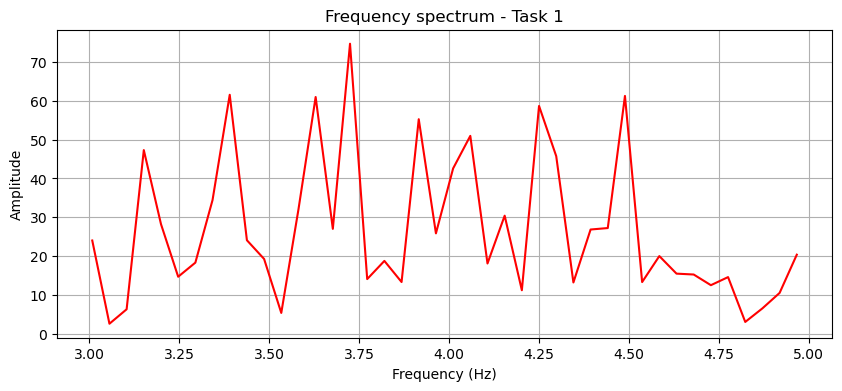

In [62]:
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_task1[mask_task1], positive_fft_task1[mask_task1], color="red")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Task 1")
plt.grid(True)
plt.show()

To reduce the influence of slow voluntary movement, the dominant tremor frequency was searched within the 3–5 Hz frequency band.
Cerebellar tremor is typically characterized by a low frequency, usually below 5 Hz (Deuschl et al., 1998).


In [63]:
signal_task1 = task1["magnitude"].values
signal_centered_task1 = signal_task1 - np.mean(signal_task1)

rms_task1 = np.sqrt(np.mean(signal_centered_task1**2))
print("RMS amplitude - Task 1:", rms_task1)

RMS amplitude - Task 1: 0.6925329650260768


Even though comparable frequencies were detected in both conditions, the much higher RMS amplitude during the task confirms the presence of a true tremor, while the resting signal remains negligible and likely corresponds to background noise.

-----------------------------------------------------------------------------------------------------------------------------------

## 2.  Rest 2 - Day 1 

### 2.1. Define the segment  


In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Define Rest 2
rest2 = df[(df["Time (s)"] >= 286) & (df["Time (s)"] <= 323)]

# Signal
signal_rest2 = rest2["magnitude"].values

# Remove mean
signal_centered_rest2 = signal_rest2 - np.mean(signal_rest2)

### 2.2. Compute dominant frequency (3–5 Hz band)  


In [68]:

# Sampling frequency
fs = 100

# FFT
fft_vals_rest2 = np.abs(np.fft.fft(signal_centered_rest2))
freqs_rest2 = np.fft.fftfreq(len(signal_centered_rest2), d=1/fs)

# Keep positive frequencies
positive_freqs_rest2 = freqs_rest2[:len(freqs_rest2)//2]
positive_fft_rest2 = fft_vals_rest2[:len(fft_vals_rest2)//2]

# Mask 3–5 Hz
mask_rest2 = (positive_freqs_rest2 >= 3) & (positive_freqs_rest2 <= 5)

# Dominant frequency
dominant_freq_rest2 = positive_freqs_rest2[mask_rest2][np.argmax(positive_fft_rest2[mask_rest2])]

print("Dominant frequency - Rest Phase 2:", dominant_freq_rest2, "Hz")

Dominant frequency - Rest Phase 2: 4.690889370932754 Hz


### 2.3. Compute RMS amplitude  
 

In [67]:
signal_rest2 = rest2["magnitude"].values
signal_centered_rest2 = signal_rest2 - np.mean(signal_rest2)

rms_rest2 = np.sqrt(np.mean(signal_centered_rest2**2))
print("RMS amplitude - Rest Phase 2:", rms_rest2)

RMS amplitude - Rest Phase 2: 0.2552581891472733


### 2.4. Plot the frequency spectrum 

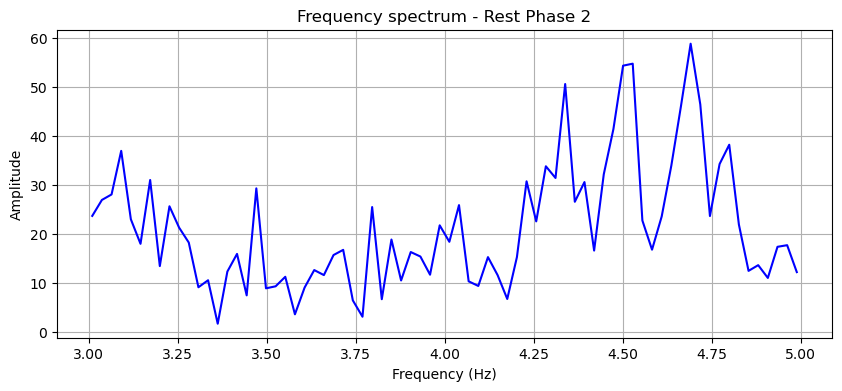

In [69]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest2[mask_rest2], positive_fft_rest2[mask_rest2], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Rest Phase 2")
plt.grid(True)
plt.show()

During the resting phase 2, the dominant frequency was found at 4.69 Hz. But unlike the first resting phase, the signal amplitude was noticeably higher.

This increase in amplitude around 300 s on the time-domain signal is caused by involuntary movements of the patient. The patient has difficulties returning to a stable resting phase with his arm after a grasping task.

That is why we should carefully interpret these frequencies, because there are many artifacts linked to the initial motor task. These artifacts can artificially influence the frequency analysis.

This suggests that the observed oscillations during this phase are more likely to be interpreted as noise or transient movements rather than a true pathological tremor.

-----------------------------------------------------------------------------------------------------------------------------------

## 3.  Task 2 - Day 1 

### 3.1. Define the segment  


In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Define Task 2
task2 = df[(df["Time (s)"] >= 323) & (df["Time (s)"] <= 343)]

# Signal
signal_task2 = task2["magnitude"].values

# Remove mean
signal_centered_task2 = signal_task2 - np.mean(signal_task2)

### 3.2. Compute dominant frequency (3–5 Hz band)  


In [71]:
# Sampling frequency
fs = 100

# FFT
fft_vals_task2 = np.abs(np.fft.fft(signal_centered_task2))
freqs_task2 = np.fft.fftfreq(len(signal_centered_task2), d=1/fs)

# Keep positive frequencies
positive_freqs_task2 = freqs_rest2[:len(freqs_task2)//2]
positive_fft_task2 = fft_vals_task2[:len(fft_vals_task2)//2]

# Mask 3–5 Hz
mask_task2 = (positive_freqs_task2 >= 3) & (positive_freqs_task2 <= 5)

# Dominant frequency
dominant_freq_task2 = positive_freqs_task2[mask_task2][np.argmax(positive_fft_task2[mask_task2])]

print("Dominant frequency - Task 2:", dominant_freq_task2, "Hz")

Dominant frequency - Task 2: 3.6334056399132315 Hz


### 3.3. Compute RMS amplitude  
 

In [72]:
signal_task2 = task2["magnitude"].values
signal_centered_task2 = signal_task2 - np.mean(signal_task2)

rms_task2 = np.sqrt(np.mean(signal_centered_task2**2))
print("RMS amplitude - Task 2:", rms_task2)

RMS amplitude - Task 2: 0.7235343040843559


### 3.4. Plot the frequency spectrum 

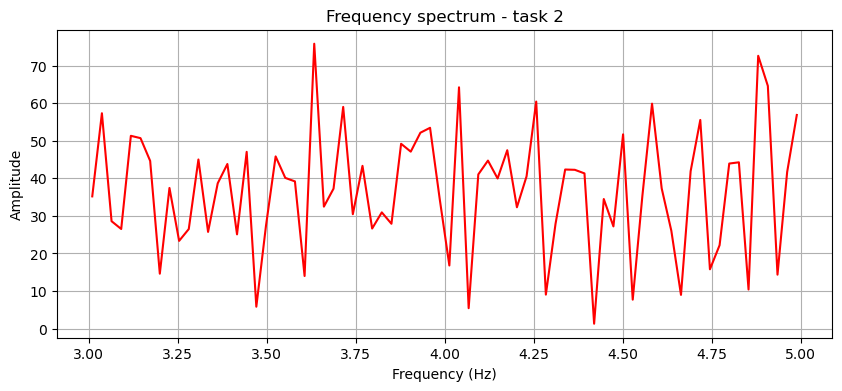

In [74]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_task2[mask_task2], positive_fft_task2[mask_task2], color="red")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - task 2")
plt.grid(True)
plt.show()

During the second grasping task, the dominant frequency was found at approximately 3.63 Hz, which remains within the typical range of cerebellar tremor (3–5 Hz).

The RMS amplitude is relatively high compared to the resting phases, confirming that the signal corresponds to an active movement condition with a clear oscillatory component.

This indicates that the tremor is functionally expressed during the task, and not during rest. The frequency remains consistent with what is expected for an intention tremor, even if it is slightly lower than in Task 1.

Overall, Task 2 confirms the presence of a tremor during voluntary movement, with a frequency in the pathological range and a significant amplitude.

-----------------------------------------------------------------------------------------------------------------------------------

## 4.  Rest 3 - Day 1 

### 4.1. Define the segment  



In [75]:
import numpy as np
import matplotlib.pyplot as plt

# Define Rest 3
rest3 = df[(df["Time (s)"] >= 343) & (df["Time (s)"] <= 355)]

# Signal
signal_rest3 = rest3["magnitude"].values

# Remove mean
signal_centered_rest3 = signal_rest3 - np.mean(signal_rest3)

### 4.2. Compute dominant frequency (3–5 Hz band)  


In [76]:

# Sampling frequency
fs = 100

# FFT
fft_vals_rest3 = np.abs(np.fft.fft(signal_centered_rest3))
freqs_rest3 = np.fft.fftfreq(len(signal_centered_rest3), d=1/fs)

# Keep positive frequencies
positive_freqs_rest3 = freqs_rest3[:len(freqs_rest3)//2]
positive_fft_rest3 = fft_vals_rest3[:len(fft_vals_rest3)//2]

# Mask 3–5 Hz
mask_rest3 = (positive_freqs_rest3 >= 3) & (positive_freqs_rest3 <= 5)

# Dominant frequency
dominant_freq_rest3 = positive_freqs_rest3[mask_rest3][np.argmax(positive_fft_rest3[mask_rest3])]

print("Dominant frequency - Rest Phase 3:", dominant_freq_rest3, "Hz")

Dominant frequency - Rest Phase 3: 4.849498327759197 Hz


### 4.3. Compute RMS amplitude  
 

In [77]:
signal_rest3 = rest3["magnitude"].values
signal_centered_rest3 = signal_rest3 - np.mean(signal_rest3)

rms_rest3 = np.sqrt(np.mean(signal_centered_rest3**2))
print("RMS amplitude - Rest Phase 3:", rms_rest3)

RMS amplitude - Rest Phase 3: 0.07124664516774774


### 4.4. Plot the frequency spectrum 

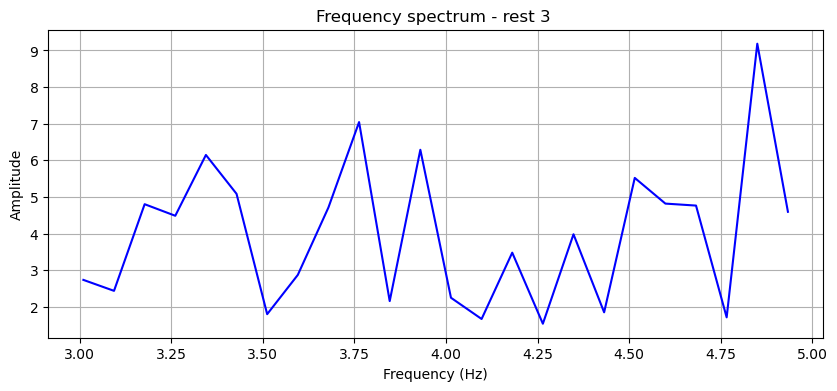

In [79]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest3[mask_rest3], positive_fft_rest3[mask_rest3], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - rest 3 ")
plt.grid(True)
plt.show()

During the third resting phase, the dominant frequency was found at approximately 4.85 Hz. This value still falls within the 3–5 Hz range typically associated with cerebellar tremor.

However, the RMS amplitude was very low (≈ 0.07), which indicates that the overall signal intensity was minimal. This suggests that the subject was in a more stable resting condition compared to Rest 2.

Therefore, although a frequency component within the tremor range was detected, the very low amplitude indicates that this activity is likely not representative of a true tremor. Instead, it more likely reflects background noise or minimal physiological variability.

This confirms that, in the absence of voluntary movement, the tremor is not significantly expressed.

Rest Phase 3 reinforces the observation that tremor expression is minimal at rest and mainly emerges during voluntary movement.

At this stage, the analysis of Day 1 is completed for all segments, including both resting and grasping phases. The next step is to organize the extracted results into a structured table, including the dominant frequency and RMS amplitude for each phase.

This table will be exported as a CSV file and will serve as the basis for further analysis. 

In the following steps, the same procedure will be applied to Day 2 and Day 3 in order to assess the reproducibility of the tremor.

Finally, all datasets will be combined and analyzed using R to perform statistical comparisons and generate clear visualizations of tremor frequency and amplitude across conditions and days.

In [82]:
import pandas as pd

results_day1 = pd.DataFrame({
    "Phase": ["Rest1", "Task1", "Rest2", "Task2", "Rest3"],
    "Dominant_Frequency_Hz": [
        dominant_freq_rest1,
        dominant_freq_task1,
        dominant_freq_rest2,
        dominant_freq_task2,
        dominant_freq_rest3
    ],
    "RMS_Amplitude": [
        rms_rest1,
        rms_task1,
        rms_rest2,
        rms_task2,
        rms_rest3
    ]
})
results_day1 = results_day1.round(2)

results_day1

,Phase,Dominant_Frequency_Hz,RMS_Amplitude
0,Rest1,3.27,0.07
1,Task1,3.72,0.69
2,Rest2,4.69,0.26
3,Task2,3.63,0.72
4,Rest3,4.85,0.07


In [83]:
results_day1.to_csv("data/processed_data/results_day1.csv", index=False)